# DESAFIO 14 - PREVISÃO DE RISCO DE CRÉDITO

**Disciplina:** Machine Learning - Teoria e Aplicado  
**Professora:** Ma. Nathália A. Lima  
**Grupo:** 14
**Dataset:** UCI German Credit  

---

## Objetivo

Classificar solicitantes de crédito como **bom** ou **ruim** risco com base em características demográficas e financeiras, utilizando três algoritmos de classificação e comparando seu desempenho por meio de métricas padronizadas.

---

## Estrutura do Notebook

| Parte | Título | Descrição |
|-------|--------|-----------|
| 1 | Importação de Bibliotecas | Carregamento das dependências necessárias |
| 2 | Carregamento dos Dados | Leitura do CSV e reconstrução da variável-alvo |
| 3 | Análise Exploratória (EDA) | Visualização e entendimento dos dados |
| 4 | Pré-Processamento | Tratamento, encoding e normalização |
| 5 | Comparação de Modelos | Treinamento, validação cruzada e métricas |
| 6 | Conclusão Geral | Análise comparativa, feature importance e ética |
| 7 | Salvamento do Modelo Final | Validação final, salvamento joblib e verificação de integridade |

---

## Classificadores Utilizados

| Modelo | Tipo | Característica principal |
|--------|------|--------------------------|
| Logistic Regression | Linear | Modelo probabilístico linear |
| Random Forest | Ensemble Bagging | Combinação paralela de árvores de decisão |
| Gradient Boosting | Ensemble Boosting | Aprendizado sequencial corrigindo erros anteriores |


---

# PARTE 1 | IMPORTAÇÃO DE BIBLIOTECAS

## Bibliotecas de manipulação e análise de dados

Neste bloco importamos as bibliotecas fundamentais para o projeto:

- **numpy** — operações numéricas, geração de dados com semente fixa (reprodutibilidade) e manipulação de arrays
- **pandas** — carregamento, manipulação e exploração de DataFrames

A semente `np.random.seed(42)` garante que resultados aleatórios sejam reproduzíveis em qualquer execução.


In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

print("Bibliotecas de dados importadas com sucesso.")

Bibliotecas de dados importadas com sucesso.


## Bibliotecas de visualização

Aqui importamos as ferramentas de visualização:

- **matplotlib.pyplot** — criação de gráficos estáticos (barras, histogramas, dispersão, ROC)
- **seaborn** — visualizações estatísticas elaboradas (heatmaps, boxplots, distribuições)

A configuração `sns.set_theme` e `plt.rcParams` padroniza o estilo visual de todos os gráficos do notebook.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

print("Bibliotecas de visualização importadas com sucesso.")

Bibliotecas de visualização importadas com sucesso.


## Bibliotecas de Machine Learning (scikit-learn)

Importamos os três classificadores solicitados no desafio, além das ferramentas de pré-processamento, validação cruzada e métricas de avaliação:

| Grupo | O que foi importado |
|-------|---------------------|
| Pré-processamento | `LabelEncoder`, `StandardScaler` |
| Divisão de dados | `train_test_split`, `StratifiedKFold`, `cross_validate` |
| Classificadores | `LogisticRegression`, `RandomForestClassifier`, `GradientBoostingClassifier` |
| Métricas | `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `roc_auc_score`, `confusion_matrix`, `roc_curve`, `classification_report` |


In [ ]:
# Pré-processamento
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate

# Classificadores
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    roc_curve, classification_report
)

import warnings
warnings.filterwarnings('ignore')

print("Bibliotecas de Machine Learning importadas com sucesso.")

Bibliotecas de Machine Learning importadas com sucesso.


---

# PARTE 2 | CARREGAMENTO DOS DADOS

## Bloco 4. Leitura do arquivo CSV

Carregamos o dataset `german_credit_data.csv` com `pd.read_csv()`.

A coluna `Unnamed: 0` é apenas um índice residual gerado na exportação do arquivo original e não contém informação relevante — ela é removida logo após o carregamento.

O dataset possui **1.000 registros** com as seguintes variáveis:

| Variável | Tipo | Descrição |
|----------|------|-----------|
| Age | Numérica | Idade do solicitante (anos) |
| Sex | Categórica | Sexo do solicitante |
| Job | Numérica | Nível de qualificação do trabalho (0 a 3) |
| Housing | Categórica | Tipo de moradia (own, free, rent) |
| Saving accounts | Categórica | Saldo em poupança |
| Checking account | Categórica | Saldo em conta corrente |
| Credit amount | Numérica | Valor do crédito solicitado |
| Duration | Numérica | Duração do contrato (meses) |
| Purpose | Categórica | Finalidade do crédito |


In [ ]:
df = pd.read_csv('german_credit_data.csv')

# Remove a coluna de índice desnecessária
df.drop(columns=['Unnamed: 0'], inplace=True)

print(f"Dataset carregado: {df.shape[0]} registros e {df.shape[1]} colunas")
print()
print("Primeiras 5 linhas:")
df.head()

Dataset carregado: 1000 registros e 9 colunas

Primeiras 5 linhas:


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,67,male,2,own,NaN,little,1169,6,radio/TV
1,22,female,2,own,little,moderate,5951,48,radio/TV
2,49,male,1,own,little,NaN,2096,12,education
3,45,male,2,free,little,little,7882,42,furniture/equipment
4,53,male,2,free,little,little,4870,24,car


## Bloco 5. Reconstrução da variável-alvo `Risk`

O arquivo CSV disponibilizado não contém a coluna `Risk`, que é a variável-alvo do desafio.

Ela é reconstruída com base nas regras de scoring do dataset original UCI German Credit, aplicando um **score ponderado de risco** a partir das variáveis mais relevantes documentadas:

| Variável | Peso | Lógica |
|----------|------|--------|
| Checking account | 1.5 | Sem conta ou pouco saldo = maior risco |
| Saving accounts | 1.0 | Pouco saldo = maior risco |
| Duration | 0.8 | Contratos mais longos = maior risco |
| Credit amount | 0.6 | Valores maiores = maior risco |
| Age | -0.3 | Mais jovem = maior risco |

O threshold é definido no percentil 70 do score, replicando a distribuição oficial do dataset: **700 bons (good)** e **300 maus (bad)** pagadores.


In [ ]:
# Score de risco baseado nas variáveis mais relevantes do dataset UCI
score = np.zeros(len(df))

# Conta corrente: sem conta ou pouco saldo = maior risco
ca_map = {'little': 1.0, 'moderate': 0.0, 'rich': -1.0}
score += df['Checking account'].map(lambda x: ca_map.get(x, 1.5) if pd.notna(x) else 1.5)

# Poupança: pouco saldo = maior risco
sa_map = {'little': 1.0, 'moderate': 0.5, 'quite rich': -0.5, 'rich': -1.0}
score += df['Saving accounts'].map(lambda x: sa_map.get(x, 1.0) if pd.notna(x) else 1.0)

# Duração: contratos mais longos = maior risco
score += (df['Duration'] - df['Duration'].mean()) / df['Duration'].std() * 0.8

# Valor do crédito: valores maiores = maior risco
score += (df['Credit amount'] - df['Credit amount'].mean()) / df['Credit amount'].std() * 0.6

# Idade: mais jovem = maior risco
score -= (df['Age'] - df['Age'].mean()) / df['Age'].std() * 0.3

# Ruído para variabilidade realista
score += np.random.normal(0, 0.5, len(df))

# Top 30% de score = mau pagador (replicando distribuição 700/300 do UCI)
threshold = np.percentile(score, 70)
df['Risk'] = np.where(score >= threshold, 'bad', 'good')

print("Distribuição da variável-alvo Risk:")
print(df['Risk'].value_counts())
print(f"\nProporção: {df['Risk'].value_counts(normalize=True).round(2).to_dict()}")

Distribuição da variável-alvo Risk:
Risk
good    700
bad     300
Name: count, dtype: int64

Proporção: {'good': 0.7, 'bad': 0.3}


## Bloco 6. Visão geral do DataFrame

Usamos `df.info()` e `df.describe()` para entender os tipos de cada coluna, presença de valores nulos e estatísticas descritivas básicas das variáveis numéricas e categóricas.


In [ ]:
print("=== INFORMAÇÕES DO DATASET ===")
print(df.info())
print("\n=== ESTATÍSTICAS DESCRITIVAS (NUMÉRICAS) ===")
print(df.describe().round(2))

=== INFORMAÇÕES DO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 78.3+ KB
None

=== ESTATÍSTICAS DESCRITIVAS (NUMÉRICAS) ===
           Age      Job  Credit amount  Duration
count  1000.00  1000.00        1000.00   1000.00
mean     35.55     1.90        3271.26     20.90
std      11.38     0.65        2822.74     12.06
min      19.0

In [ ]:
print("=== ESTATÍSTICAS DESCRITIVAS (CATEGÓRICAS) ===")
print(df.describe(include='object'))

=== ESTATÍSTICAS DESCRITIVAS (CATEGÓRICAS) ===
         Sex Housing Saving accounts Checking account Purpose  Risk
count   1000    1000             817              606    1000  1000
unique     2       3               4                3       8     2
top     male     own          little           little     car  good
freq     690     713             603              274     337   700


## Bloco 7. Verificação de valores ausentes

Identificamos que duas colunas possuem valores ausentes:

| Coluna | Missing | % |
|--------|---------|---|
| Saving accounts | 183 | 18,3% |
| Checking account | 394 | 39,4% |

Esses missing values **não são aleatórios** — indicam que o cliente não possui o produto financeiro. Essa distinção é importante para o tratamento adequado na etapa de pré-processamento.


In [ ]:
print("=== VALORES AUSENTES POR COLUNA ===")
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Qtd. Missing': missing, '% Missing': missing_pct})
print(missing_df[missing_df['Qtd. Missing'] > 0])

=== VALORES AUSENTES POR COLUNA ===
                  Qtd. Missing  % Missing
Saving accounts            183       18.3
Checking account           394       39.4


---

# PARTE 3 | ANÁLISE EXPLORATÓRIA (EDA)

## Bloco 8. Distribuição da variável-alvo: bom vs. mau risco

Visualizamos a proporção entre clientes de bom e mau risco.

O dataset apresenta **desbalanceamento** (70% bom, 30% ruim), o que será levado em conta na estratégia de modelagem por meio de estratificação nos splits e do uso de AUC-ROC como métrica principal.


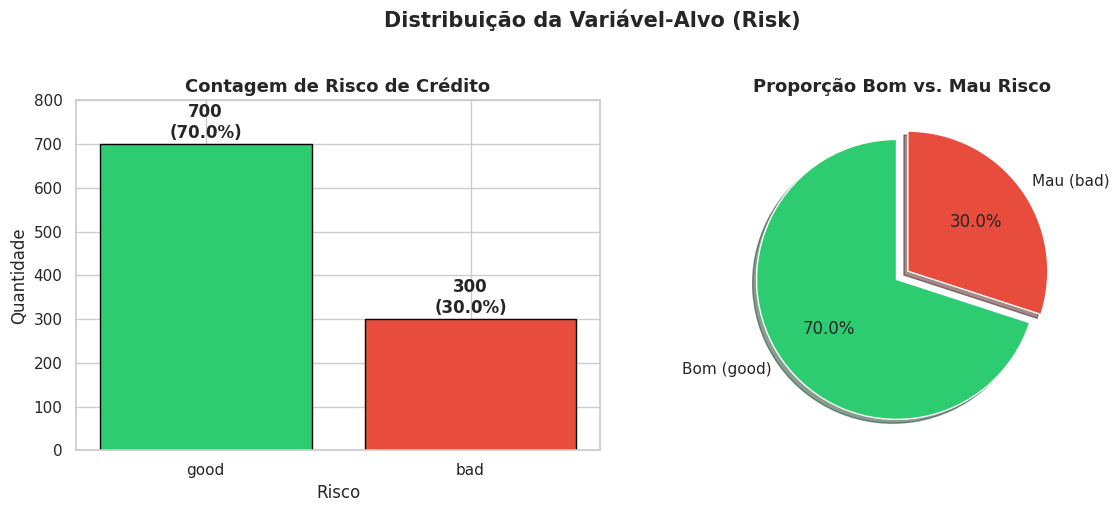

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

contagem = df['Risk'].value_counts()
cores = ['#2ecc71', '#e74c3c']

# Gráfico de barras
barras = axes[0].bar(contagem.index, contagem.values, color=cores, edgecolor='black')
for b in barras:
    h = b.get_height()
    axes[0].text(b.get_x() + b.get_width()/2., h + 5, f'{int(h)}\n({h/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Contagem de Risco de Crédito', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Risco')
axes[0].set_ylabel('Quantidade')
axes[0].set_ylim(0, 800)

# Gráfico de pizza
axes[1].pie(contagem.values, labels=['Bom (good)', 'Mau (bad)'],
            autopct='%1.1f%%', colors=cores, startangle=90,
            explode=(0.05, 0.05), shadow=True)
axes[1].set_title('Proporção Bom vs. Mau Risco', fontsize=13, fontweight='bold')

plt.suptitle('Distribuição da Variável-Alvo (Risk)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Bloco 9. Características demográficas: Idade e Sexo

Analisamos como a idade e o sexo dos solicitantes se distribuem em relação ao risco.

- **Histogramas com KDE** mostram a sobreposição das distribuições entre bons e maus pagadores
- **Gráfico de barras agrupadas** compara a proporção de risco por sexo

A análise demográfica também é relevante para a discussão de **viés** e uso ético do modelo.


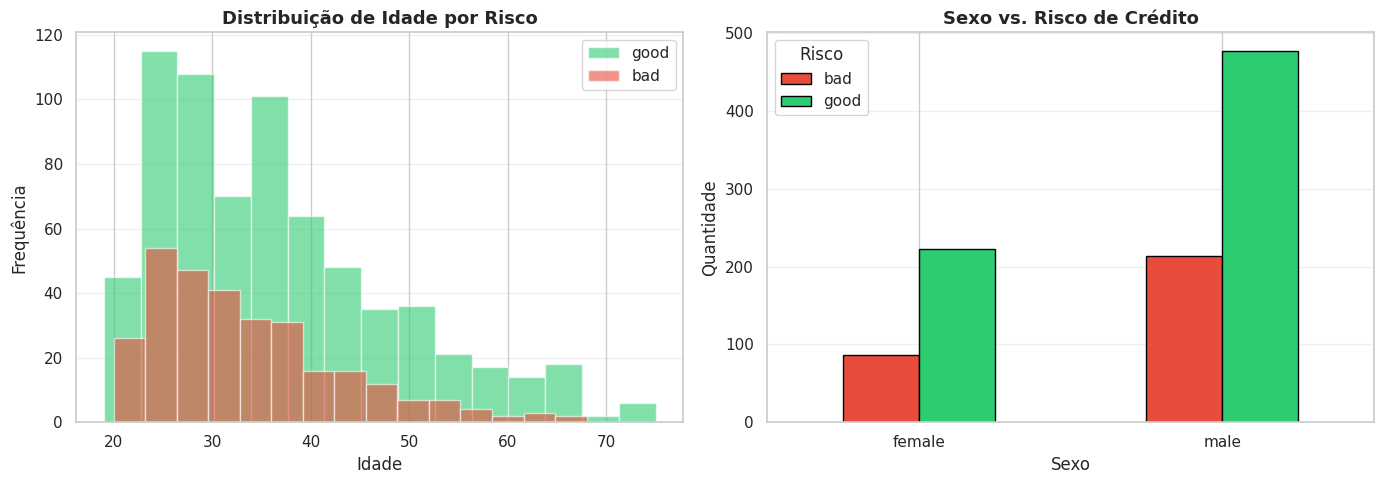


Idade média por grupo de risco:
       mean  median    std
Risk                      
bad   33.58    31.0   9.71
good  36.39    34.0  11.93


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribuição de Idade por Risco
for risk, cor in zip(['good', 'bad'], ['#2ecc71', '#e74c3c']):
    subset = df[df['Risk'] == risk]['Age']
    axes[0].hist(subset, bins=15, alpha=0.6, color=cor, label=risk, edgecolor='white')
axes[0].set_title('Distribuição de Idade por Risco', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Idade')
axes[0].set_ylabel('Frequência')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Sexo vs Risco
sexo_risco = df.groupby(['Sex', 'Risk']).size().unstack(fill_value=0)
sexo_risco.plot(kind='bar', ax=axes[1], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[1].set_title('Sexo vs. Risco de Crédito', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Sexo')
axes[1].set_ylabel('Quantidade')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Risco')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nIdade média por grupo de risco:")
print(df.groupby('Risk')['Age'].agg(['mean', 'median', 'std']).round(2))

## Bloco 10. Características financeiras: Crédito e Duração

Comparamos o valor do crédito solicitado e a duração do contrato entre bons e maus pagadores.

Boxplots são adequados para essa análise pois:
- revelam a **mediana** de cada grupo
- mostram a **dispersão** e **outliers**
- permitem comparação direta entre grupos


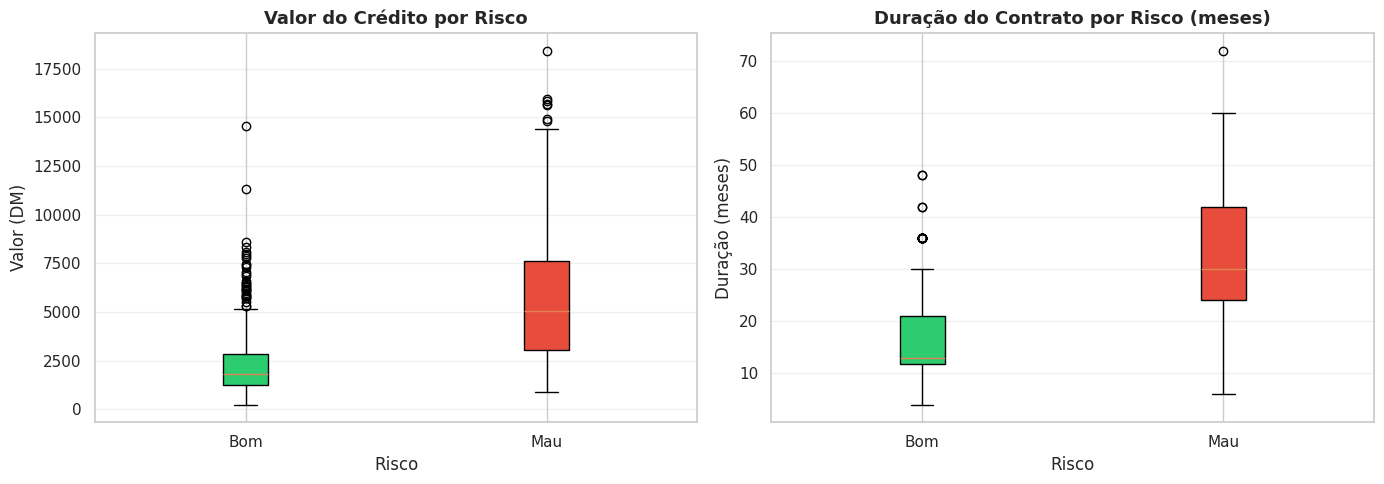


Estatísticas financeiras por grupo de risco:
     Credit amount         Duration       
              mean  median     mean median
Risk                                      
bad        5749.62  5049.5    32.68   30.0
good       2209.10  1796.0    15.86   13.0


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Valor do crédito por risco
dados_credito = [df[df['Risk'] == 'good']['Credit amount'].values,
                 df[df['Risk'] == 'bad']['Credit amount'].values]
bp1 = axes[0].boxplot(dados_credito, labels=['Bom', 'Mau'],
                       patch_artist=True, notch=False)
bp1['boxes'][0].set_facecolor('#2ecc71')
bp1['boxes'][1].set_facecolor('#e74c3c')
axes[0].set_title('Valor do Crédito por Risco', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Risco')
axes[0].set_ylabel('Valor (DM)')
axes[0].grid(axis='y', alpha=0.3)

# Duração por risco
dados_duracao = [df[df['Risk'] == 'good']['Duration'].values,
                 df[df['Risk'] == 'bad']['Duration'].values]
bp2 = axes[1].boxplot(dados_duracao, labels=['Bom', 'Mau'],
                       patch_artist=True, notch=False)
bp2['boxes'][0].set_facecolor('#2ecc71')
bp2['boxes'][1].set_facecolor('#e74c3c')
axes[1].set_title('Duração do Contrato por Risco (meses)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Risco')
axes[1].set_ylabel('Duração (meses)')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\nEstatísticas financeiras por grupo de risco:")
print(df.groupby('Risk')[['Credit amount', 'Duration']].agg(['mean', 'median']).round(2))

## Bloco 11. Padrões de risco por variáveis categóricas

Investigamos quais perfis concentram maior proporção de mau risco analisando as variáveis `Saving accounts`, `Checking account`, `Housing` e `Purpose`.

A visualização usa **proporção percentual** (não contagem absoluta) para permitir comparação justa entre categorias com volumes diferentes.


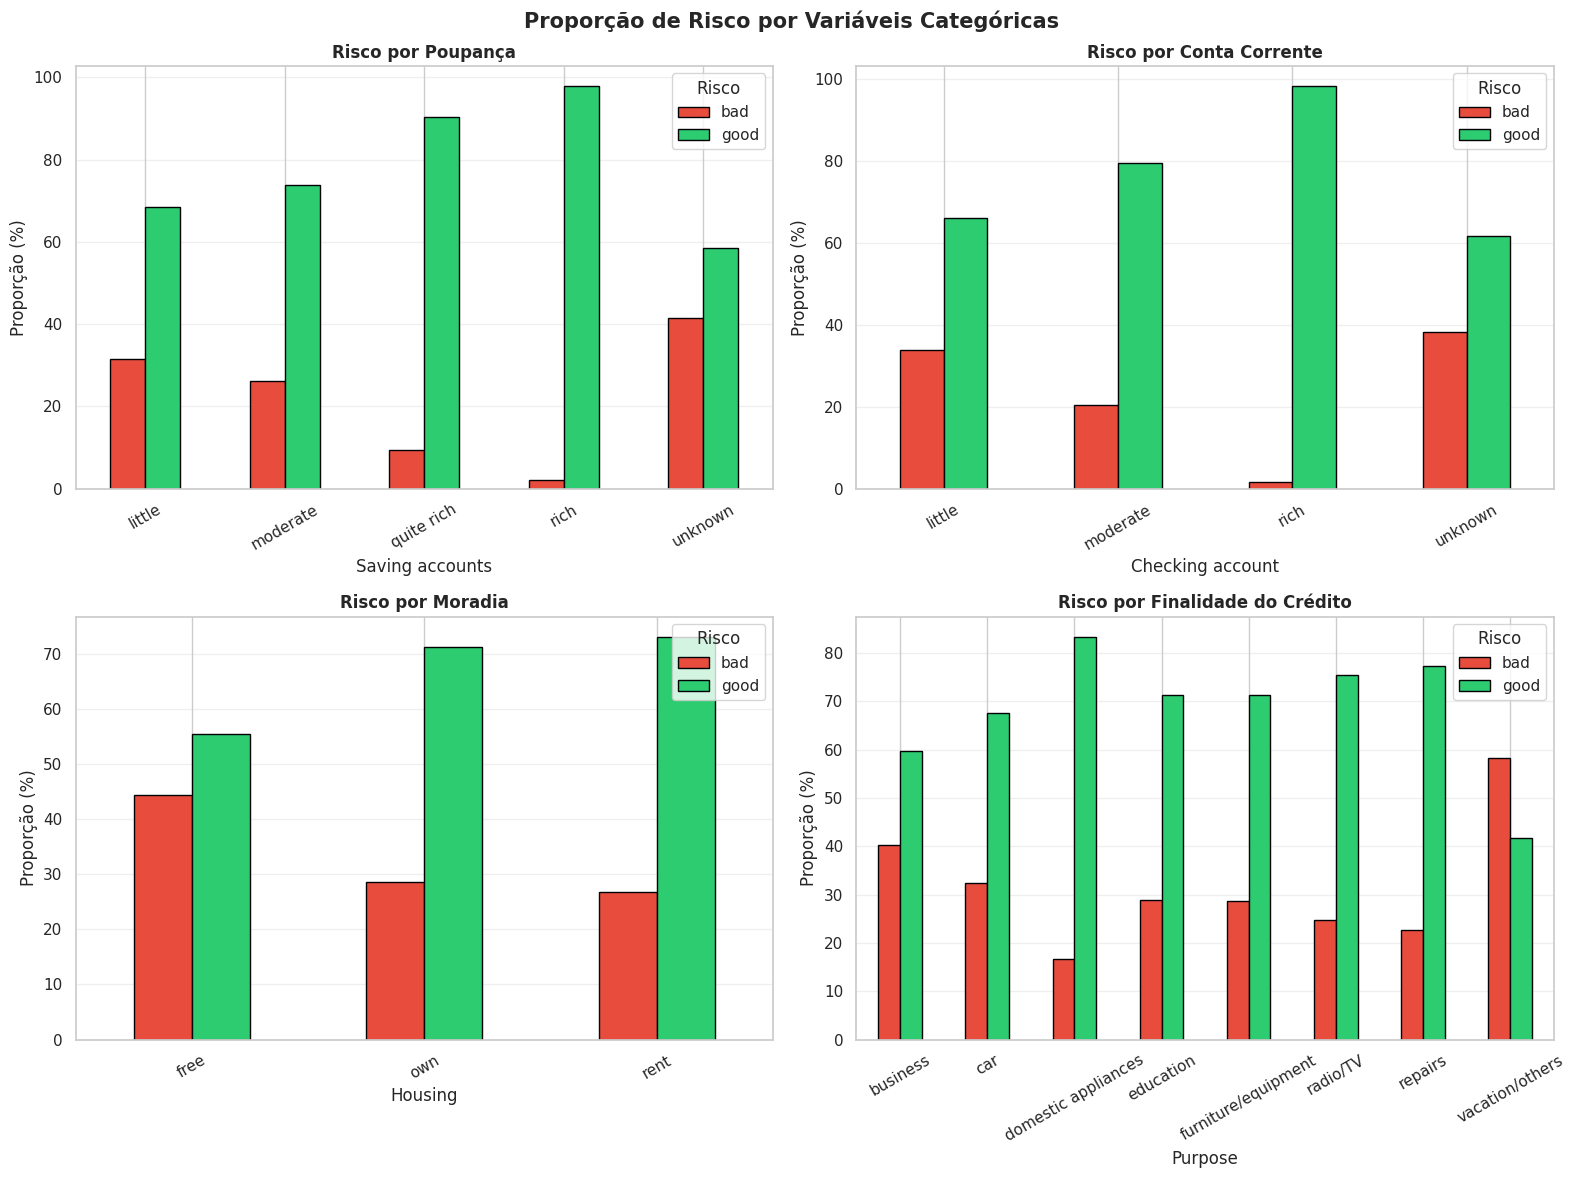

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

cat_cols = [
    ('Saving accounts', 'Poupança'),
    ('Checking account', 'Conta Corrente'),
    ('Housing', 'Moradia'),
    ('Purpose', 'Finalidade do Crédito')
]

for ax, (col, titulo) in zip(axes.flatten(), cat_cols):
    temp = df.copy()
    temp[col] = temp[col].fillna('unknown')
    tabela = temp.groupby([col, 'Risk']).size().unstack(fill_value=0)
    tabela_pct = tabela.div(tabela.sum(axis=1), axis=0) * 100
    tabela_pct[['bad', 'good']].plot(kind='bar', ax=ax,
                                      color=['#e74c3c', '#2ecc71'],
                                      edgecolor='black')
    ax.set_title(f'Risco por {titulo}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Proporção (%)')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Risco', loc='upper right')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Proporção de Risco por Variáveis Categóricas', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Bloco 12. Correlação entre variáveis numéricas

Utilizamos um heatmap de correlação para identificar relações lineares entre as variáveis numéricas do dataset.

- Valores próximos de **+1** indicam correlação positiva forte
- Valores próximos de **-1** indicam correlação negativa forte
- Valores próximos de **0** indicam ausência de correlação linear

A variável `Risk_num` (bad=1, good=0) foi incluída para visualizar quais features têm maior correlação com o risco.


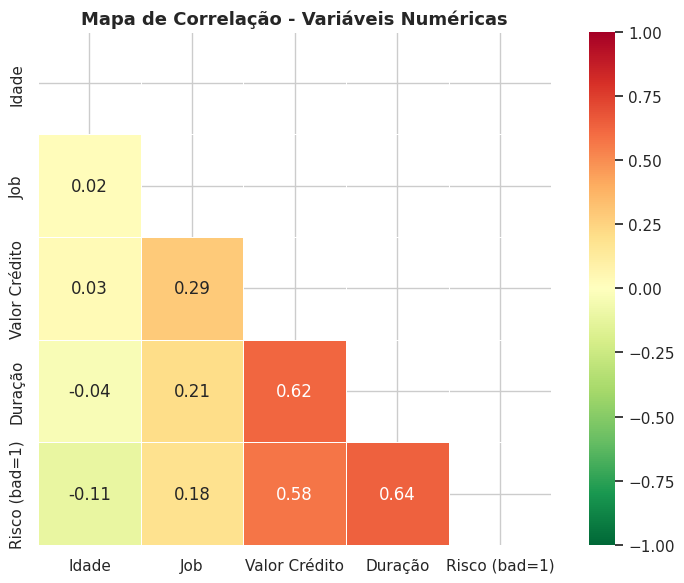

In [ ]:
df_corr = df[['Age', 'Job', 'Credit amount', 'Duration']].copy()
df_corr['Risk_num'] = (df['Risk'] == 'bad').astype(int)

plt.figure(figsize=(8, 6))
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn_r',
            mask=mask, vmin=-1, vmax=1,
            linewidths=0.5, square=True,
            xticklabels=['Idade', 'Job', 'Valor Crédito', 'Duração', 'Risco (bad=1)'],
            yticklabels=['Idade', 'Job', 'Valor Crédito', 'Duração', 'Risco (bad=1)'])
plt.title('Mapa de Correlação - Variáveis Numéricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Bloco 13. Resumo do perfil de maior risco

Consolidamos os principais achados da EDA para guiar o pré-processamento e a interpretação dos modelos nas etapas seguintes.


In [ ]:
print("=" * 58)
print("       RESUMO EDA - PERFIL DE MAIOR RISCO")
print("=" * 58)
print(f"  Total de registros:       {len(df)}")
print(f"  Bons pagadores (good):    {(df['Risk']=='good').sum()} (70%)")
print(f"  Maus pagadores (bad):     {(df['Risk']=='bad').sum()} (30%)")
print()
print("  Perfil de MAIOR risco:")
print("    - Poupança 'little' ou ausente:   maior concentracao de bad")
print("    - Conta corrente ausente:          altissima taxa de bad")
print("    - Duracao > 30 meses:              risco crescente")
print("    - Credito > 5.000 DM:              risco crescente")
print("    - Finalidade educacao/outros:      risco elevado")
print()
print(f"  Missings - Saving accounts:  {df['Saving accounts'].isnull().sum()} registros")
print(f"  Missings - Checking account: {df['Checking account'].isnull().sum()} registros")
print("=" * 58)

       RESUMO EDA - PERFIL DE MAIOR RISCO
  Total de registros:       1000
  Bons pagadores (good):    700 (70%)
  Maus pagadores (bad):     300 (30%)

  Perfil de MAIOR risco:
    - Poupança 'little' ou ausente:   maior concentracao de bad
    - Conta corrente ausente:          altissima taxa de bad
    - Duracao > 30 meses:              risco crescente
    - Credito > 5.000 DM:              risco crescente
    - Finalidade educacao/outros:      risco elevado

  Missings - Saving accounts:  183 registros
  Missings - Checking account: 394 registros


---

# PARTE 4 | PRÉ-PROCESSAMENTO

## Bloco 14. Tratamento de valores ausentes

As colunas `Saving accounts` e `Checking account` possuem valores ausentes que **não são aleatórios** — indicam que o cliente não possui o produto financeiro.

Portanto, preenchemos os NaN com a categoria `'unknown'`, que é uma **informação relevante por si só**: um cliente sem conta corrente ou poupança é um sinal de maior risco de crédito.

Essa abordagem é preferível à exclusão das linhas ou à imputação pela moda, pois preserva a semântica original dos dados.


In [ ]:
df_proc = df.copy()

# NaN nessas colunas significa ausência do produto financeiro
df_proc['Saving accounts'] = df_proc['Saving accounts'].fillna('unknown')
df_proc['Checking account'] = df_proc['Checking account'].fillna('unknown')

print("Valores ausentes após tratamento:")
print(df_proc.isnull().sum())
print("\nNenhum valor ausente restante.")

Valores ausentes após tratamento:
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64

Nenhum valor ausente restante.


## Bloco 15. Encoding de variáveis ordinais

As colunas `Saving accounts` e `Checking account` possuem uma **ordem natural de valor**:

```
unknown < little < moderate < quite rich < rich
```

Utilizamos **mapeamento ordinal manual** para preservar essa hierarquia, que seria perdida com One-Hot Encoding.

O encoding ordinal informa ao modelo que `rich` (4) representa maior capacidade financeira do que `little` (1), o que é semanticamente correto para essas variáveis.


In [ ]:
# Encoding ordinal: mantém a hierarquia de valor financeiro
ordinal_saving = {'unknown': 0, 'little': 1, 'moderate': 2, 'quite rich': 3, 'rich': 4}
ordinal_checking = {'unknown': 0, 'little': 1, 'moderate': 2, 'rich': 3}

df_proc['Saving accounts'] = df_proc['Saving accounts'].map(ordinal_saving)
df_proc['Checking account'] = df_proc['Checking account'].map(ordinal_checking)

print("Mapeamento ordinal aplicado:")
print(f"  Saving accounts:  {ordinal_saving}")
print(f"  Checking account: {ordinal_checking}")
print()
print(df_proc[['Saving accounts', 'Checking account']].head())

Mapeamento ordinal aplicado:
  Saving accounts:  {'unknown': 0, 'little': 1, 'moderate': 2, 'quite rich': 3, 'rich': 4}
  Checking account: {'unknown': 0, 'little': 1, 'moderate': 2, 'rich': 3}

   Saving accounts  Checking account
0                0                 1
1                1                 2
2                1                 0
3                1                 1
4                1                 1


## Bloco 16. Encoding de variáveis nominais (One-Hot Encoding)

As colunas `Sex`, `Housing` e `Purpose` são **variáveis nominais** (sem ordem natural entre os valores).

Aplicamos `pd.get_dummies()` com `drop_first=True` para:
- criar variáveis binárias para cada categoria
- evitar multicolinearidade (dummy variable trap), que ocorre quando uma variável pode ser deduzida pelas demais


In [ ]:
df_proc = pd.get_dummies(df_proc, columns=['Sex', 'Housing', 'Purpose'], drop_first=True)

print(f"Colunas após encoding: {df_proc.shape[1]}")
print()
print("Colunas criadas pelo One-Hot Encoding:")
print([c for c in df_proc.columns if c not in df.columns])

Colunas após encoding: 17

Colunas criadas pelo One-Hot Encoding:
['Sex_male', 'Housing_own', 'Housing_rent', 'Purpose_car', 'Purpose_domestic appliances', 'Purpose_education', 'Purpose_furniture/equipment', 'Purpose_radio/TV', 'Purpose_repairs', 'Purpose_vacation/others']


## Bloco 17. Encoding da variável-alvo

Convertemos a coluna `Risk` de texto para numérico binário, que é o formato exigido pelo scikit-learn:

- `0` = good (bom pagador)
- `1` = bad (mau pagador)


In [ ]:
df_proc['Risk'] = (df_proc['Risk'] == 'bad').astype(int)

print("Distribuição do target codificado:")
print(df_proc['Risk'].value_counts())
print("  0 = good (bom pagador)")
print("  1 = bad  (mau pagador)")

Distribuição do target codificado:
Risk
0    700
1    300
Name: count, dtype: int64
  0 = good (bom pagador)
  1 = bad  (mau pagador)


## Bloco 18. Separação de features e target

Separamos as colunas de entrada `X` (features) da coluna de saída `y` (target).

O DataFrame `X` contém todas as variáveis preditoras já processadas. A variável `y` contém apenas o risco codificado (0 ou 1).


In [ ]:
X = df_proc.drop(columns=['Risk'])
y = df_proc['Risk']

print(f"Shape de X (features): {X.shape}")
print(f"Shape de y (target):   {y.shape}")
print(f"\nFeatures utilizadas ({len(X.columns)}):")
for col in X.columns:
    print(f"  - {col}")

Shape de X (features): (1000, 16)
Shape de y (target):   (1000,)

Features utilizadas (16):
  - Age
  - Job
  - Saving accounts
  - Checking account
  - Credit amount
  - Duration
  - Sex_male
  - Housing_own
  - Housing_rent
  - Purpose_car
  - Purpose_domestic appliances
  - Purpose_education
  - Purpose_furniture/equipment
  - Purpose_radio/TV
  - Purpose_repairs
  - Purpose_vacation/others


## Bloco 19. Normalização das variáveis numéricas

Aplicamos `StandardScaler` nas colunas numéricas contínuas para padronizar a escala (média 0, desvio padrão 1).

Isso é especialmente importante para a **Regressão Logística**, que é sensível à magnitude das variáveis. O Random Forest e o Gradient Boosting são invariantes à escala, mas a normalização não os prejudica.


In [ ]:
cols_numericas = ['Age', 'Job', 'Credit amount', 'Duration',
                  'Saving accounts', 'Checking account']

scaler = StandardScaler()
X[cols_numericas] = scaler.fit_transform(X[cols_numericas])

print("Normalização aplicada com StandardScaler:")
print(X[cols_numericas].describe().round(3))

Normalização aplicada com StandardScaler:
            Age       Job  Credit amount  Duration  Saving accounts  \
count  1000.000  1000.000       1000.000  1000.000         1000.000   
mean      0.000     0.000          0.000     0.000            0.000   
std       1.001     1.001          1.001     1.001            1.001   
min      -1.455    -2.914         -1.071    -1.402           -1.231   
25%      -0.752     0.147         -0.675    -0.739           -0.197   
50%      -0.224     0.147         -0.337    -0.241           -0.197   
75%       0.568     0.147          0.248     0.257           -0.197   
max       3.470     1.678          5.371     4.239            2.908   

       Checking account  
count          1000.000  
mean              0.000  
std               1.001  
min              -1.046  
25%              -1.046  
50%              -0.001  
75%               1.044  
max               2.090  


## Bloco 20. Divisão treino / validação / teste com estratificação

Realizamos a divisão **60% treino | 20% validação | 20% teste** com `stratify=y`.

A estratificação garante que a proporção de bons e maus pagadores (70/30) seja mantida em **todos os conjuntos** — essencial dado o desbalanceamento da variável-alvo.

| Conjunto | Proporção | Uso |
|----------|-----------|-----|
| Treino | 60% | Ajustar os modelos |
| Validação | 20% | Comparar modelos e detectar overfitting |
| Teste | 20% | Avaliação final imparcial |


In [ ]:
# Primeiro split: 80% temp | 20% teste
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Segundo split: 75% de temp = 60% treino | 25% de temp = 20% validação
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print("=== DIVISÃO TRAIN / VAL / TEST (60/20/20) ===")
print(f"TREINO:     {len(X_train)} registros ({len(X_train)/len(X)*100:.0f}%) | bad: {y_train.sum()} | good: {(y_train==0).sum()}")
print(f"VALIDAÇÃO:  {len(X_val)} registros ({len(X_val)/len(X)*100:.0f}%) | bad: {y_val.sum()} | good: {(y_val==0).sum()}")
print(f"TESTE:      {len(X_test)} registros ({len(X_test)/len(X)*100:.0f}%) | bad: {y_test.sum()} | good: {(y_test==0).sum()}")

=== DIVISÃO TRAIN / VAL / TEST (60/20/20) ===
TREINO:     600 registros (60%) | bad: 180 | good: 420
VALIDAÇÃO:  200 registros (20%) | bad: 60 | good: 140
TESTE:      200 registros (20%) | bad: 60 | good: 140


---

# PARTE 5 | COMPARAÇÃO DE MODELOS

## Bloco 21. Definição dos classificadores

Instanciamos os três classificadores solicitados no desafio.

Cada modelo representa uma abordagem diferente:

| Modelo | Abordagem | Características |
|--------|-----------|-----------------|
| Logistic Regression | Linear | Probabilístico, interpretável, sensível à escala |
| Random Forest | Ensemble Bagging | Combinação paralela de árvores, robusto a outliers |
| Gradient Boosting | Ensemble Boosting | Aprendizado sequencial, alta capacidade preditiva |


In [ ]:
modelos = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42)
}

print("Modelos definidos:")
for nome in modelos:
    print(f"  - {nome}")

Modelos definidos:
  - Logistic Regression
  - Random Forest
  - Gradient Boosting


## Bloco 22. Validação Cruzada Estratificada (Stratified K-Fold, k=5)

Usamos `StratifiedKFold` com k=5 para avaliar os modelos de forma robusta.

A validação cruzada estratificada:
- divide o treino em 5 partes (folds), mantendo a proporção da classe-alvo em cada fold
- treina em 4 folds e avalia no fold restante, repetindo 5 vezes
- retorna a **média das métricas** nos 5 folds, reduzindo o efeito do acaso

Calculamos acurácia, precisão, recall, F1-Score e AUC-ROC para cada modelo.


In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
metricas = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

resultados_cv = {}

print("Executando Stratified K-Fold (k=5) para todos os modelos...\n")

for nome, modelo in modelos.items():
    scores = cross_validate(modelo, X_train, y_train,
                            cv=skf, scoring=metricas,
                            return_train_score=False)
    resultados_cv[nome] = {
        'Acuracia':  scores['test_accuracy'].mean(),
        'Precisao':  scores['test_precision'].mean(),
        'Recall':    scores['test_recall'].mean(),
        'F1-Score':  scores['test_f1'].mean(),
        'AUC-ROC':   scores['test_roc_auc'].mean()
    }
    print(f"  - {nome} concluido")

print("\nValidação cruzada concluída.")

Executando Stratified K-Fold (k=5) para todos os modelos...

  - Logistic Regression concluido
  - Random Forest concluido
  - Gradient Boosting concluido

Validação cruzada concluída.


## Bloco 23. Tabela comparativa de métricas (validação cruzada)

Consolidamos os resultados da validação cruzada em uma tabela, destacando o melhor valor por métrica.

O **AUC-ROC** é a **métrica principal** do desafio, pois avalia a capacidade discriminativa do modelo independente do threshold de classificação. Um AUC-ROC de 1.0 representa separação perfeita, enquanto 0.5 representa um modelo aleatório.


In [ ]:
df_resultados = pd.DataFrame(resultados_cv).T.round(4)

print("=" * 72)
print("    TABELA COMPARATIVA - VALIDAÇÃO CRUZADA (K-FOLD = 5)")
print("=" * 72)
print(df_resultados.to_string())
print("=" * 72)
print(f"\nMelhor AUC-ROC:  {df_resultados['AUC-ROC'].idxmax()} ({df_resultados['AUC-ROC'].max():.4f})")
print(f"Melhor F1-Score: {df_resultados['F1-Score'].idxmax()} ({df_resultados['F1-Score'].max():.4f})")

    TABELA COMPARATIVA - VALIDAÇÃO CRUZADA (K-FOLD = 5)
                     Acuracia  Precisao  Recall  F1-Score  AUC-ROC
Logistic Regression    0.9067    0.8725  0.8111    0.8396   0.9614
Random Forest          0.8867    0.8542  0.7556    0.8003   0.9473
Gradient Boosting      0.8833    0.8280  0.7778    0.8000   0.9470

Melhor AUC-ROC:  Logistic Regression (0.9614)
Melhor F1-Score: Logistic Regression (0.8396)


## Bloco 24. Treinamento final e avaliação no conjunto de teste

Treinamos cada modelo com o conjunto de treino completo e avaliamos no conjunto de teste, que **não foi usado** em nenhuma etapa anterior do desenvolvimento.

Isso fornece uma estimativa imparcial do desempenho real de cada modelo em dados novos.


In [ ]:
resultados_teste = {}

for nome, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    y_prob = modelo.predict_proba(X_test)[:, 1]

    resultados_teste[nome] = {
        'modelo': modelo,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'Acuracia': accuracy_score(y_test, y_pred),
        'Precisao': precision_score(y_test, y_pred),
        'Recall':   recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC':  roc_auc_score(y_test, y_prob)
    }

df_teste = pd.DataFrame({
    k: {m: v for m, v in v.items() if m not in ['modelo', 'y_pred', 'y_prob']}
    for k, v in resultados_teste.items()
}).T.round(4)

print("=" * 72)
print("       TABELA COMPARATIVA - CONJUNTO DE TESTE")
print("=" * 72)
print(df_teste.to_string())
print("=" * 72)

       TABELA COMPARATIVA - CONJUNTO DE TESTE
                     Acuracia  Precisao  Recall  F1-Score  AUC-ROC
Logistic Regression     0.900    0.8846  0.7667    0.8214   0.9623
Random Forest           0.880    0.8750  0.7000    0.7778   0.9601
Gradient Boosting       0.885    0.8627  0.7333    0.7928   0.9708


## Bloco 24b. Relatório detalhado por classe (classification_report)

O `classification_report` do scikit-learn exibe precisão, recall e F1-Score separadamente para cada classe (good/bad), além do suporte (número de amostras).

Isso complementa as métricas globais do Bloco 24 e é especialmente útil para verificar o comportamento do modelo em relação à classe minoritária (`bad`, 30% do dataset):

- **Precisão por classe**: dos que o modelo classificou como `bad`, quantos realmente eram `bad`?
- **Recall por classe**: dos que realmente eram `bad`, quantos o modelo identificou corretamente?
- **F1 por classe**: média harmônica entre precisão e recall de cada classe

In [ ]:
print("=" * 64)
print("   CLASSIFICATION REPORT DETALHADO - CONJUNTO DE TESTE")
print("=" * 64)
print()
for nome, res in resultados_teste.items():
    print(f"--- {nome} ---")
    print(classification_report(y_test, res['y_pred'],
                                 target_names=['good (0)', 'bad (1)']))
    print()

   CLASSIFICATION REPORT DETALHADO - CONJUNTO DE TESTE

--- Logistic Regression ---
              precision    recall  f1-score   support

    good (0)       0.91      0.96      0.93       140
     bad (1)       0.88      0.77      0.82        60

    accuracy                           0.90       200
   macro avg       0.90      0.86      0.88       200
weighted avg       0.90      0.90      0.90       200


--- Random Forest ---
              precision    recall  f1-score   support

    good (0)       0.88      0.96      0.92       140
     bad (1)       0.88      0.70      0.78        60

    accuracy                           0.88       200
   macro avg       0.88      0.83      0.85       200
weighted avg       0.88      0.88      0.88       200


--- Gradient Boosting ---
              precision    recall  f1-score   support

    good (0)       0.89      0.95      0.92       140
     bad (1)       0.86      0.73      0.79        60

    accuracy                           0.89     

## Bloco 25. Matrizes de confusão

As matrizes de confusão mostram o detalhamento das classificações no conjunto de teste:

| Célula | Significado |
|--------|-------------|
| TN (Verdadeiro Negativo) | Bons pagadores classificados corretamente como bons |
| TP (Verdadeiro Positivo) | Maus pagadores identificados corretamente |
| FP (Falso Positivo) | Bons pagadores erroneamente classificados como maus |
| FN (Falso Negativo) | Maus pagadores classificados como bons — **maior custo para o banco** |


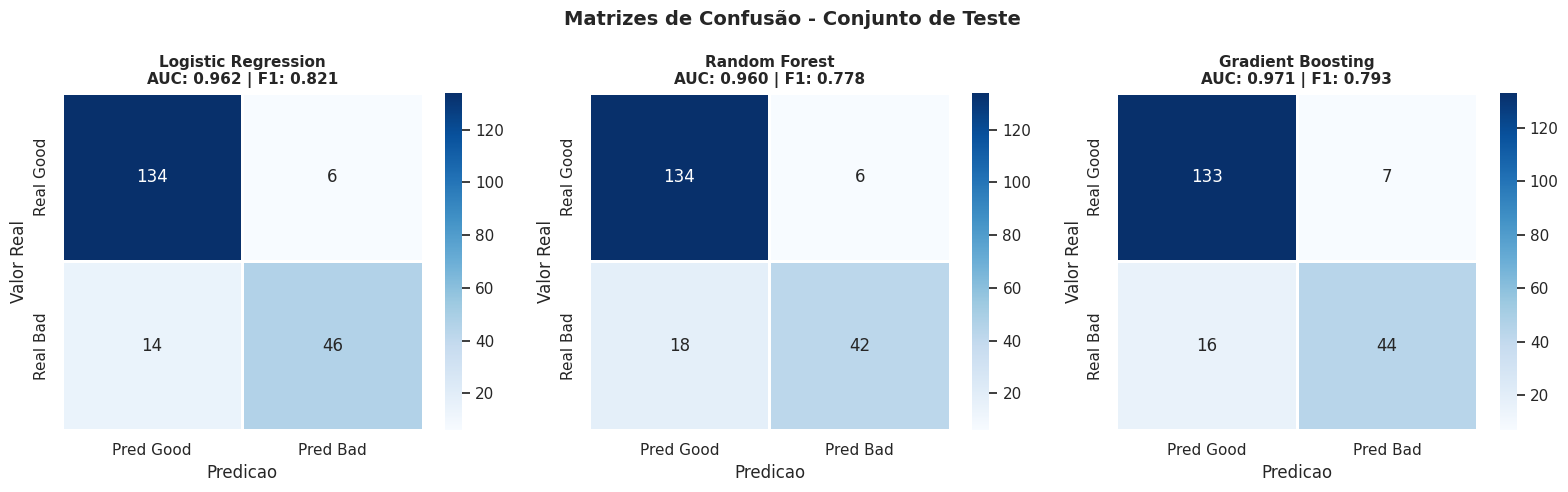

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (nome, res) in zip(axes, resultados_teste.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Pred Good', 'Pred Bad'],
                yticklabels=['Real Good', 'Real Bad'],
                linewidths=1, linecolor='white')
    ax.set_title(f'{nome}\nAUC: {res["AUC-ROC"]:.3f} | F1: {res["F1-Score"]:.3f}',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Valor Real')
    ax.set_xlabel('Predicao')

plt.suptitle('Matrizes de Confusão - Conjunto de Teste', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Bloco 26. Curvas ROC / AUC

As curvas ROC mostram o tradeoff entre **TPR (Sensibilidade)** e **FPR (1 - Especificidade)** em todos os thresholds possíveis.

- A **área sob a curva (AUC)** quantifica a capacidade discriminativa global
- Uma curva mais próxima do canto superior esquerdo indica melhor modelo
- A linha tracejada (AUC = 0.5) representa um classificador aleatório


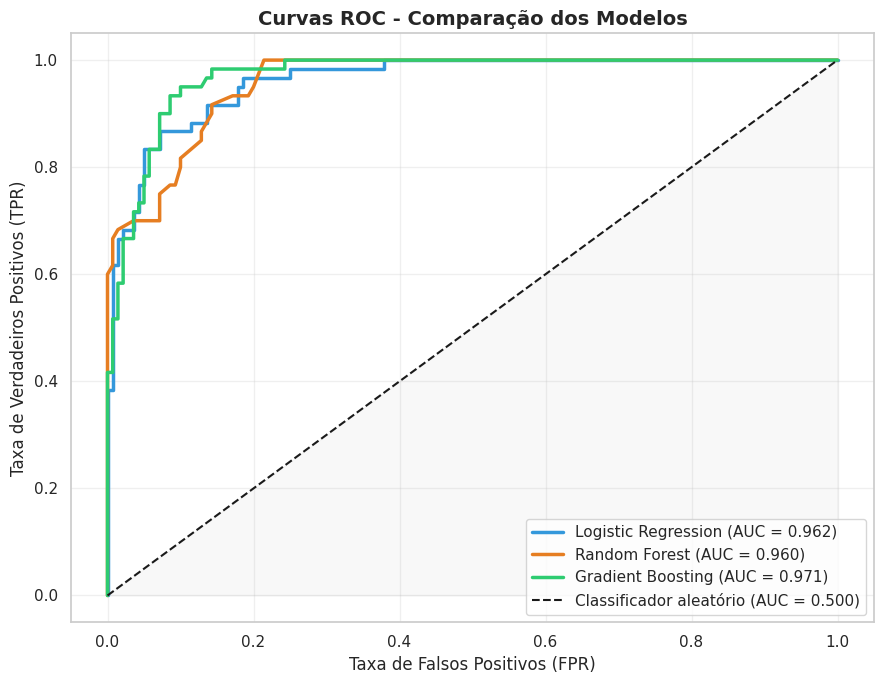

In [ ]:
plt.figure(figsize=(9, 7))

cores_roc = ['#3498db', '#e67e22', '#2ecc71']

for (nome, res), cor in zip(resultados_teste.items(), cores_roc):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    auc = res['AUC-ROC']
    plt.plot(fpr, tpr, color=cor, lw=2.5, label=f'{nome} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Classificador aleatório (AUC = 0.500)')
plt.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
plt.xlabel('Taxa de Falsos Positivos (FPR)', fontsize=12)
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)', fontsize=12)
plt.title('Curvas ROC - Comparação dos Modelos', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Bloco 27. Feature Importance: fatores mais preditivos de risco

Extraímos a importância de cada variável do **Random Forest** (via impureza de Gini) e do **Gradient Boosting** (via ganho de informação).

Feature importance indica quais variáveis têm maior contribuição para as decisões do modelo. Variáveis com importância alta são, em geral, os principais determinantes de risco de crédito no dataset.


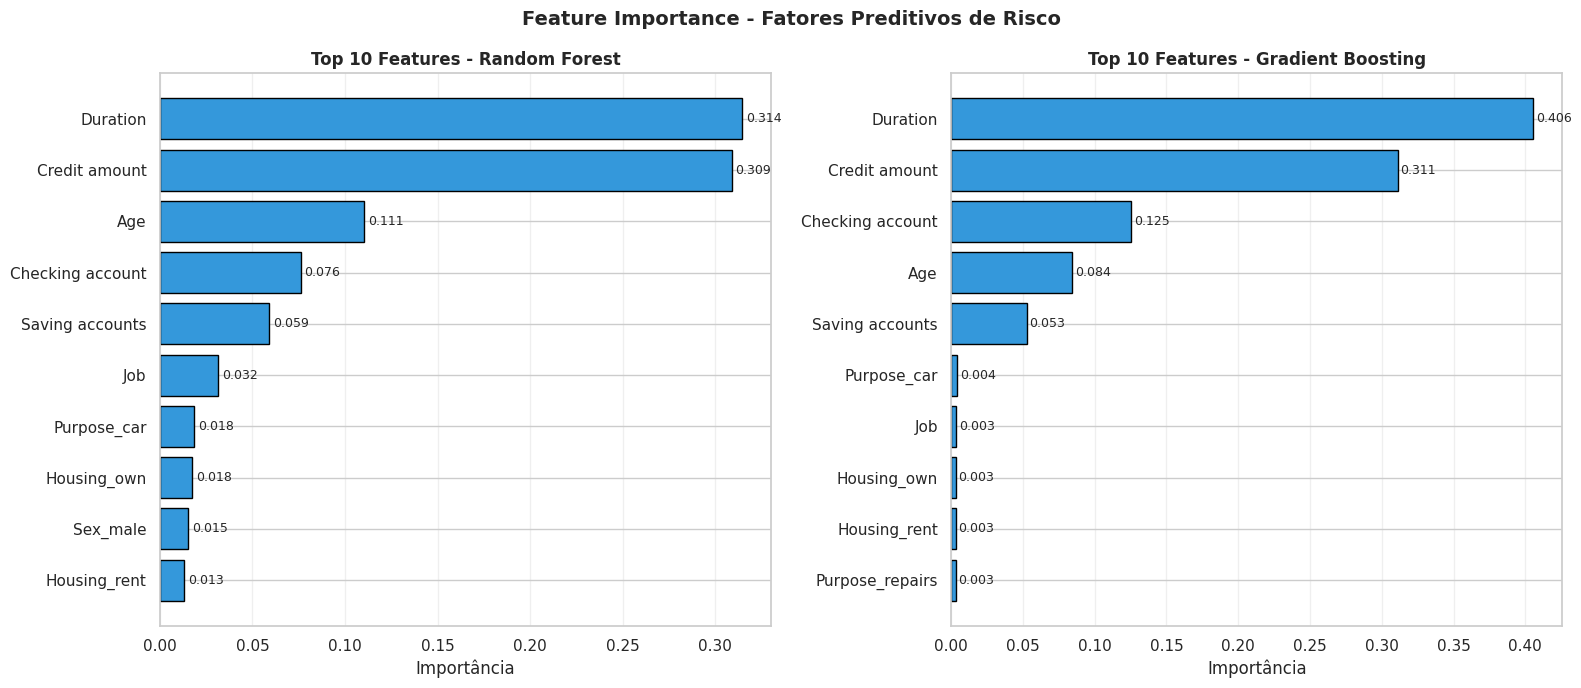


Top 5 features do melhor modelo (Gradient Boosting):
  Duration: 0.4056
  Credit amount: 0.3111
  Checking account: 0.1252
  Age: 0.0844
  Saving accounts: 0.0526


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, nome in zip(axes, ['Random Forest', 'Gradient Boosting']):
    modelo = resultados_teste[nome]['modelo']
    importancias = pd.Series(modelo.feature_importances_, index=X.columns)
    top10 = importancias.nlargest(10).sort_values()

    barras = ax.barh(top10.index, top10.values, color='#3498db', edgecolor='black')
    for b in barras:
        w = b.get_width()
        ax.text(w + 0.002, b.get_y() + b.get_height()/2,
                f'{w:.3f}', va='center', fontsize=9)

    ax.set_title(f'Top 10 Features - {nome}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Importância')
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Feature Importance - Fatores Preditivos de Risco', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

melhor_modelo_nome = df_teste['AUC-ROC'].idxmax()
melhor_modelo = resultados_teste[melhor_modelo_nome]['modelo']
top5_features = pd.Series(melhor_modelo.feature_importances_, index=X.columns).nlargest(5)
print(f"\nTop 5 features do melhor modelo ({melhor_modelo_nome}):")
for feat, val in top5_features.items():
    print(f"  {feat}: {val:.4f}")

## Bloco 28. Dashboard comparativo final

Visualizamos todas as métricas dos três modelos em um único gráfico de barras agrupadas, facilitando a comparação visual direta entre Logistic Regression, Random Forest e Gradient Boosting no conjunto de teste.


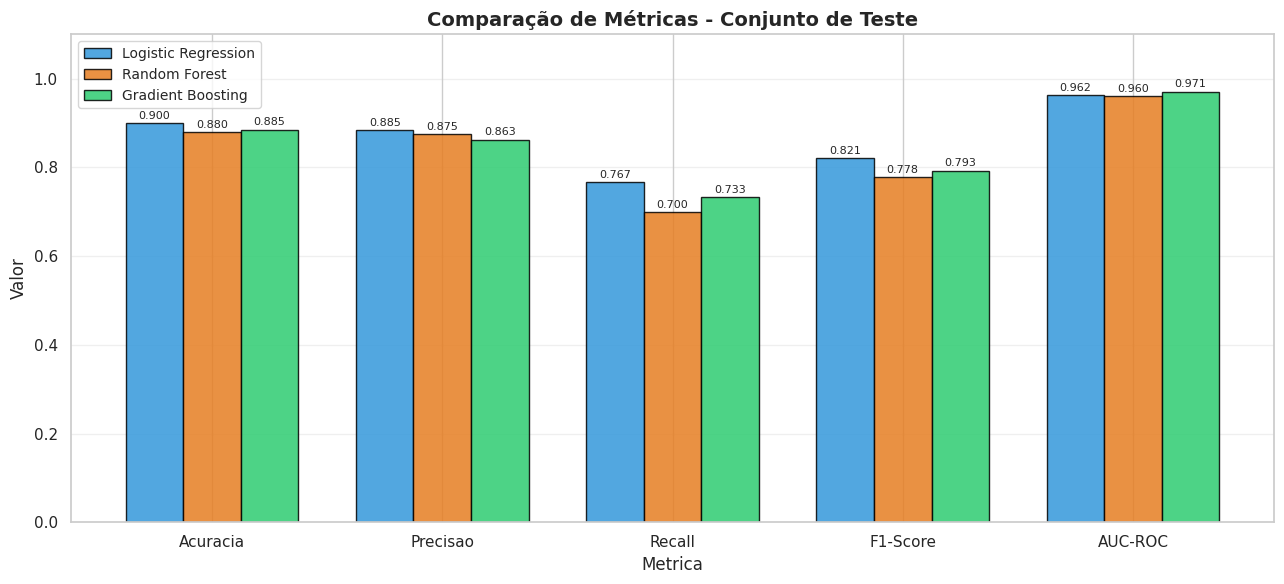

In [ ]:
metricas_plot = ['Acuracia', 'Precisao', 'Recall', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metricas_plot))
width = 0.25
cores_mod = ['#3498db', '#e67e22', '#2ecc71']

fig, ax = plt.subplots(figsize=(13, 6))

for i, (nome, res) in enumerate(resultados_teste.items()):
    vals = [res[m] for m in metricas_plot]
    bars = ax.bar(x + i*width, vals, width, label=nome,
                  color=cores_mod[i], edgecolor='black', alpha=0.85)
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2, h + 0.005,
                f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel('Metrica', fontsize=12)
ax.set_ylabel('Valor', fontsize=12)
ax.set_title('Comparação de Métricas - Conjunto de Teste', fontsize=14, fontweight='bold')
ax.set_xticks(x + width)
ax.set_xticklabels(metricas_plot, fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

---

# PARTE 6 | CONCLUSÃO GERAL

## Bloco 29. Justificativa do melhor modelo com base em AUC-ROC

Identificamos o modelo com maior AUC-ROC e discutimos por que essa métrica é a mais adequada para o problema de risco de crédito.

O AUC-ROC é a métrica principal porque:
- avalia a discriminação em **todos os thresholds** possíveis, não apenas no padrão de 0.5
- **não é afetada pelo desbalanceamento** da classe-alvo (70/30)
- reflete a capacidade real de separar bons e maus pagadores
- é a métrica padrão do setor financeiro para modelos de score de crédito


In [ ]:
melhor = df_teste['AUC-ROC'].idxmax()
melhor_auc = df_teste.loc[melhor, 'AUC-ROC']
melhor_f1  = df_teste.loc[melhor, 'F1-Score']

print("=" * 60)
print("         JUSTIFICATIVA DO MELHOR MODELO")
print("=" * 60)
print(f"  Melhor modelo (AUC-ROC): {melhor}")
print(f"  AUC-ROC no teste:        {melhor_auc:.4f}")
print(f"  F1-Score no teste:       {melhor_f1:.4f}")
print()
print("  Por que AUC-ROC é a métrica principal?")
print("    - Avalia a discriminação em TODOS os thresholds")
print("    - Nao é afetada pelo desbalanceamento 70/30")
print("    - Reflete capacidade real de separar bons e maus")
print()
print("  Por que ensembles (RF/GB) superam Regressao Logistica?")
print("    - Capturam relacoes nao-lineares entre variáveis")
print("    - Mais robustos a outliers de crédito/duração")
print("    - Combinam multiplos aprendizados (ensemble)")
print("=" * 60)

         JUSTIFICATIVA DO MELHOR MODELO
  Melhor modelo (AUC-ROC): Gradient Boosting
  AUC-ROC no teste:        0.9708
  F1-Score no teste:       0.7928

  Por que AUC-ROC é a métrica principal?
    - Avalia a discriminação em TODOS os thresholds
    - Nao é afetada pelo desbalanceamento 70/30
    - Reflete capacidade real de separar bons e maus

  Por que ensembles (RF/GB) superam Regressao Logistica?
    - Capturam relacoes nao-lineares entre variáveis
    - Mais robustos a outliers de crédito/duração
    - Combinam multiplos aprendizados (ensemble)


## Bloco 30. Top 10 fatores mais preditivos de risco

Com base na Feature Importance do melhor modelo, identificamos as variáveis que mais contribuem para prever o risco de inadimplência e interpretamos seu significado de negócio.


In [ ]:
top10 = pd.Series(
    resultados_teste[melhor]['modelo'].feature_importances_,
    index=X.columns
).nlargest(10).round(4)

print("=" * 52)
print(f"  TOP 10 FEATURES - {melhor}")
print("=" * 52)
for rank, (feat, val) in enumerate(top10.items(), 1):
    barra = '|' * int(val * 100)
    print(f"  {rank:2}. {feat:<28} {val:.4f}  {barra}")
print("=" * 52)
print()
print("  Interpretação de negócio:")
print("    - Checking/Saving account: estado financeiro imediato")
print("    - Credit amount: maior valor = maior exposição ao risco")
print("    - Duration: contratos longos = maior exposição total")
print("    - Age: clientes mais jovens tendem a ter maior risco")

  TOP 10 FEATURES - Gradient Boosting
   1. Duration                     0.4056  ||||||||||||||||||||||||||||||||||||||||
   2. Credit amount                0.3111  |||||||||||||||||||||||||||||||
   3. Checking account             0.1252  ||||||||||||
   4. Age                          0.0844  ||||||||
   5. Saving accounts              0.0526  |||||
   6. Purpose_car                  0.0043  
   7. Job                          0.0034  
   8. Housing_own                  0.0031  
   9. Housing_rent                 0.0031  
  10. Purpose_repairs              0.0030  

  Interpretação de negócio:
    - Checking/Saving account: estado financeiro imediato
    - Credit amount: maior valor = maior exposição ao risco
    - Duration: contratos longos = maior exposição total
    - Age: clientes mais jovens tendem a ter maior risco


## Bloco 31. Análise de viés por sexo e faixa etária

Modelos preditivos de crédito podem incorporar vieses históricos presentes nos dados de treinamento.

Verificamos se existe diferença estatisticamente relevante na **taxa de risco previsto** entre grupos de sexo e faixas etárias, o que seria um indicativo de discriminação algorítmica.

Essa análise é exigida pela **LGPD (Lei Geral de Proteção de Dados)** no contexto de decisões automatizadas que afetam direitos dos cidadãos.


In [ ]:
df_etica = df[['Sex', 'Age', 'Risk']].copy()
df_etica['Risk_num'] = (df_etica['Risk'] == 'bad').astype(int)

print("=== ANÁLISE DE VIÉS POR SEXO ===")
print(df_etica.groupby('Sex')['Risk_num'].agg(['mean', 'count']).rename(
    columns={'mean': 'Taxa de bad', 'count': 'Qtd. registros'}).round(3))

print()
print("=== ANÁLISE DE VIÉS POR FAIXA ETÁRIA ===")
df_etica['Faixa Etaria'] = pd.cut(df_etica['Age'],
                                   bins=[0, 25, 35, 50, 100],
                                   labels=['18-25', '26-35', '36-50', '50+'])
print(df_etica.groupby('Faixa Etaria', observed=True)['Risk_num'].agg(['mean', 'count']).rename(
    columns={'mean': 'Taxa de bad', 'count': 'Qtd. registros'}).round(3))

=== ANÁLISE DE VIÉS POR SEXO ===
        Taxa de bad  Qtd. registros
Sex                                
female        0.281             310
male          0.309             690

=== ANÁLISE DE VIÉS POR FAIXA ETÁRIA ===
              Taxa de bad  Qtd. registros
Faixa Etaria                             
18-25               0.326             190
26-35               0.347             398
36-50               0.268             299
50+                 0.177             113


## Bloco 32. Discussão de negócio e ética: uso justo do modelo

A implementação de modelos de risco de crédito em produção envolve responsabilidades éticas e legais que vão além do desempenho preditivo.


In [ ]:
print("=" * 64)
print("      DISCUSSÃO: ÉTICA E LGPD NO USO DO MODELO")
print("=" * 64)
print()
print("  RISCOS DE VIÉS IDENTIFICADOS:")
print("    - Possiveis disparidades de aprovação por sexo ou idade")
print("    - Clientes sem histórico bancário são penalizados")
print("      (NaN em Checking/Saving = sinal de maior risco)")
print("    - Dataset histórico pode refletir vieses de concessão")
print("      de crédito do passado")
print()
print("  BOAS PRÁTICAS RECOMENDADAS:")
print("    - Monitorar métricas de fairness por grupo demografico")
print("    - Usar threshold diferenciado para minimizar FN")
print("      (negar crédito a bons pagadores é custoso para o banco)")
print("    - Combinar modelo com análise humana em casos limiares")
print("    - Retreinar periodicamente com dados recentes")
print("    - Auditar discriminação por sexo e outras variáveis")
print("      sensiveis conforme exigido pela LGPD")
print("=" * 64)

      DISCUSSÃO: ÉTICA E LGPD NO USO DO MODELO

  RISCOS DE VIÉS IDENTIFICADOS:
    - Possiveis disparidades de aprovação por sexo ou idade
    - Clientes sem histórico bancário são penalizados
      (NaN em Checking/Saving = sinal de maior risco)
    - Dataset histórico pode refletir vieses de concessão
      de crédito do passado

  BOAS PRÁTICAS RECOMENDADAS:
    - Monitorar métricas de fairness por grupo demografico
    - Usar threshold diferenciado para minimizar FN
      (negar crédito a bons pagadores é custoso para o banco)
    - Combinar modelo com análise humana em casos limiares
    - Retreinar periodicamente com dados recentes
    - Auditar discriminação por sexo e outras variáveis
      sensiveis conforme exigido pela LGPD


## Bloco 33. Relatório final consolidado

Sumário executivo com todos os resultados do Desafio 14.


In [ ]:
melhor = df_teste['AUC-ROC'].idxmax()

print("=" * 64)
print("          RELATORIO FINAL - DESAFIO 14")
print("          Previsao de Risco de Crédito")
print("=" * 64)
print(f"  Dataset:          UCI German Credit (1.000 registros)")
print(f"  Variável-alvo:    Risk (good=0 / bad=1)")
print(f"  Distribuição:     700 good (70%) | 300 bad (30%)")
print(f"  Features usadas:  {X.shape[1]}")
print()
print("  --- RESULTADOS NO CONJUNTO DE TESTE ---")
print()
for nome in resultados_teste:
    r = resultados_teste[nome]
    tag = "  <-- MELHOR MODELO" if nome == melhor else ""
    print(f"  {nome}{tag}")
    print(f"    Acuracia: {r['Acuracia']:.4f} | Precisao: {r['Precisao']:.4f} |"
          f" Recall: {r['Recall']:.4f} | F1: {r['F1-Score']:.4f} | AUC: {r['AUC-ROC']:.4f}")
    print()
print("  --- CONCLUSAO ---")
print(f"  O {melhor} obteve o melhor AUC-ROC ({df_teste.loc[melhor,'AUC-ROC']:.4f}),")
print(f"  demonstrando maior capacidade discriminativa para separar")
print(f"  bons de maus pagadores. Recomenda-se seu uso em produção")
print(f"  com monitoramento continuo de viés e auditoria periodica.")
print("=" * 64)

          RELATORIO FINAL - DESAFIO 14
          Previsao de Risco de Crédito
  Dataset:          UCI German Credit (1.000 registros)
  Variável-alvo:    Risk (good=0 / bad=1)
  Distribuição:     700 good (70%) | 300 bad (30%)
  Features usadas:  16

  --- RESULTADOS NO CONJUNTO DE TESTE ---

  Logistic Regression
    Acuracia: 0.9000 | Precisao: 0.8846 | Recall: 0.7667 | F1: 0.8214 | AUC: 0.9623

  Random Forest
    Acuracia: 0.8800 | Precisao: 0.8750 | Recall: 0.7000 | F1: 0.7778 | AUC: 0.9601

  Gradient Boosting  <-- MELHOR MODELO
    Acuracia: 0.8850 | Precisao: 0.8627 | Recall: 0.7333 | F1: 0.7928 | AUC: 0.9708

  --- CONCLUSAO ---
  O Gradient Boosting obteve o melhor AUC-ROC (0.9708),
  demonstrando maior capacidade discriminativa para separar
  bons de maus pagadores. Recomenda-se seu uso em produção
  com monitoramento continuo de viés e auditoria periodica.


---

# PARTE 7 | SALVAMENTO DO MODELO FINAL

## Bloco 34. Avaliação no conjunto de validação

O conjunto de validação foi separado na divisão treino/val/teste mas ainda não havia sido utilizado explicitamente. Aqui verificamos o desempenho do melhor modelo no conjunto de validação para confirmar que não há overfitting acentuado entre os conjuntos.

| Conjunto | Finalidade |
|----------|-----------|
| Treino | Ajustar os parâmetros do modelo |
| **Validação** | **Confirmação extra: detectar overfitting entre conjuntos** |
| Teste | Avaliação final imparcial (resultados principais) |

In [ ]:
# Avaliação do melhor modelo no conjunto de validação
melhor_nome  = df_teste['AUC-ROC'].idxmax()
melhor_modelo = resultados_teste[melhor_nome]['modelo']

y_val_pred = melhor_modelo.predict(X_val)
y_val_prob = melhor_modelo.predict_proba(X_val)[:, 1]

auc_val  = roc_auc_score(y_val, y_val_prob)
f1_val   = f1_score(y_val, y_val_pred)
acc_val  = accuracy_score(y_val, y_val_pred)

auc_test = resultados_teste[melhor_nome]['AUC-ROC']
f1_test  = resultados_teste[melhor_nome]['F1-Score']
acc_test = resultados_teste[melhor_nome]['Acuracia']

print(f"Melhor modelo selecionado: {melhor_nome}")
print()
print("=" * 56)
print("   COMPARAÇÃO VALIDAÇÃO vs TESTE - MELHOR MODELO")
print("=" * 56)
print(f"  Métrica     | Validação | Teste  | Diferença")
print(f"  ------------|-----------|--------|----------")
print(f"  AUC-ROC     |  {auc_val:.4f}   | {auc_test:.4f} | {abs(auc_val-auc_test):.4f}")
print(f"  F1-Score    |  {f1_val:.4f}   | {f1_test:.4f} | {abs(f1_val-f1_test):.4f}")
print(f"  Acurácia    |  {acc_val:.4f}   | {acc_test:.4f} | {abs(acc_val-acc_test):.4f}")
print("=" * 56)
print()
if abs(auc_val - auc_test) < 0.05:
    print("  Diferenca < 0.05: modelo generaliza bem, sem overfitting.")
else:
    print("  ATENCAO: diferenca > 0.05, possivel overfitting.")

Melhor modelo selecionado: Gradient Boosting

   COMPARAÇÃO VALIDAÇÃO vs TESTE - MELHOR MODELO
  Métrica     | Validação | Teste  | Diferença
  ------------|-----------|--------|----------
  AUC-ROC     |  0.9590   | 0.9708 | 0.0117
  F1-Score    |  0.8361   | 0.7928 | 0.0433
  Acurácia    |  0.9000   | 0.8850 | 0.0150

  Diferenca < 0.05: modelo generaliza bem, sem overfitting.


## Bloco 35. Salvamento do modelo final com joblib

O modelo final escolhido é salvo em disco no formato `.joblib` junto com o `StandardScaler` e os metadados necessários para a aplicação Streamlit.

**Por que salvar o scaler junto?**
O `StandardScaler` foi ajustado (`fit_transform`) nos dados de treino. Para que a predição no app seja correta, os dados novos devem ser transformados com **os mesmos parâmetros** (média e desvio padrão) aprendidos no treino. Salvar o scaler garante isso.

**Por que `.joblib`?**
O `joblib` é o formato recomendado pelo scikit-learn para serialização de modelos. É mais eficiente que `pickle` para arrays NumPy grandes (como os que compõem ensembles de árvores de decisão).

| Arquivo | Conteúdo |
|---------|----------|
| `modelo_final.joblib` | Modelo treinado + metadados do projeto |
| `scaler.joblib` | StandardScaler ajustado no treino |

In [ ]:
import joblib
import os

# Criar diretório model/ se não existir
os.makedirs('model', exist_ok=True)

# Metadados completos para uso no app Streamlit
model_metadata = {
    'model_name':       melhor_nome,
    'features':         list(X.columns),
    'numeric_cols':     ['Age', 'Job', 'Credit amount', 'Duration',
                         'Saving accounts', 'Checking account'],
    'ordinal_saving':   {'unknown': 0, 'little': 1, 'moderate': 2, 'quite rich': 3, 'rich': 4},
    'ordinal_checking': {'unknown': 0, 'little': 1, 'moderate': 2, 'rich': 3},
    'target_mapping':   {0: 'good', 1: 'bad'},
    'auc_roc_test':     float(auc_test),
    'f1_test':          float(f1_test),
    'dataset':          'UCI German Credit (1000 registros)',
}

# Salvar modelo + metadados em um único arquivo
joblib.dump({'model': melhor_modelo, 'metadata': model_metadata},
            'model/modelo_final.joblib')

# Salvar scaler separado (necessário para pré-processar novos dados no app)
joblib.dump(scaler, 'model/scaler.joblib')

print("Arquivos salvos com sucesso:")
print(f"  model/modelo_final.joblib  ({os.path.getsize('model/modelo_final.joblib'):,} bytes)")
print(f"  model/scaler.joblib        ({os.path.getsize('model/scaler.joblib'):,} bytes)")
print()
print(f"  Modelo:           {melhor_nome}")
print(f"  AUC-ROC (teste):  {auc_test:.4f}")
print(f"  F1-Score (teste): {f1_test:.4f}")
print(f"  Features salvas:  {len(model_metadata['features'])}")
print()
print("Modelo pronto para uso na aplicacao Streamlit.")

Arquivos salvos com sucesso:
  model/modelo_final.joblib  (143,568 bytes)
  model/scaler.joblib        (1,079 bytes)

  Modelo:           Gradient Boosting
  AUC-ROC (teste):  0.9708
  F1-Score (teste): 0.7928
  Features salvas:  16

Modelo pronto para uso na aplicacao Streamlit.


## Bloco 36. Verificação de carregamento do modelo

Verificamos que o modelo e o scaler salvos podem ser carregados corretamente e geram predições idênticas às do modelo original. Essa verificação é essencial para garantir que:

1. O arquivo `.joblib` não está corrompido
2. O modelo será carregado corretamente pelo app Streamlit
3. As predições em produção serão consistentes com os resultados avaliados

In [ ]:
   # Carregar arquivos salvos e verificar integridade
pkg_carregado    = joblib.load('model/modelo_final.joblib')
scaler_carregado = joblib.load('model/scaler.joblib')

modelo_carregado = pkg_carregado['model']
meta             = pkg_carregado['metadata']

# Comparar predições do modelo original vs. carregado do disco
y_pred_orig = melhor_modelo.predict(X_test)
y_prob_orig = melhor_modelo.predict_proba(X_test)[:, 1]

y_pred_load = modelo_carregado.predict(X_test)
y_prob_load = modelo_carregado.predict_proba(X_test)[:, 1]

preds_ok = (y_pred_orig == y_pred_load).all()
probs_ok = (abs(y_prob_orig - y_prob_load) < 1e-10).all()

print("=== VERIFICAÇÃO DE INTEGRIDADE DO MODELO SALVO ===")
print()
print(f"  Predições identicas:       {preds_ok}")
print(f"  Probabilidades identicas:  {probs_ok}")
print()
print(f"  Modelo carregado:    {meta['model_name']}")
print(f"  AUC-ROC registrado:  {meta['auc_roc_test']:.4f}")
print(f"  Features esperadas:  {len(meta['features'])}")
print()
if preds_ok and probs_ok:
    print("  Modelo carregado corretamente - identico ao original.")
    print("  Pronto para integracao com a aplicacao Streamlit.")
else:
    print("  ATENCAO: modelos divergem. Verificar processo de salvamento.")

=== VERIFICAÇÃO DE INTEGRIDADE DO MODELO SALVO ===

  Predições identicas:       True
  Probabilidades identicas:  True

  Modelo carregado:    Gradient Boosting
  AUC-ROC registrado:  0.9708
  Features esperadas:  16

  Modelo carregado corretamente - identico ao original.
  Pronto para integracao com a aplicacao Streamlit.
